# Create a wavelength lookup table for DREAM

This notebook shows how to create a wavelength lookup table for the DREAM instrument.

In [1]:
import scipp as sc
from ess.reduce import unwrap
from ess.reduce.nexus.types import AnyRun
from ess.dream.beamline import InstrumentConfiguration, choppers

## Select the choppers

We select the choppers for the 'high-flux' configuration.

In [2]:
disk_choppers = choppers(InstrumentConfiguration.high_flux_BC240)

Note that possible configurations are `high_flux_BC215`, `high_flux_BC240`, and `high_resolution`.

## Setting up the workflow

In [3]:
wf = unwrap.LookupTableWorkflow()

wf[unwrap.LtotalRange] = sc.scalar(5.0, unit="m"), sc.scalar(80.0, unit="m")
wf[unwrap.NumberOfSimulatedNeutrons] = 200_000  # Increase this number for more reliable results
wf[unwrap.SourcePosition] = sc.vector([0, 0, 0], unit='m')
wf[unwrap.DiskChoppers[AnyRun]] = disk_choppers
wf[unwrap.DistanceResolution] = sc.scalar(0.1, unit="m")
wf[unwrap.TimeResolution] = sc.scalar(250.0, unit='us')
wf[unwrap.PulsePeriod] = 1.0 / sc.scalar(14.0, unit="Hz")
wf[unwrap.PulseStride] = 1
wf[unwrap.PulseStrideOffset] = None

## Compute the table

In [4]:
table = wf.compute(unwrap.LookupTable)
table.array

<scipp.DataArray>
Dimensions: Sizes[distance:754, event_time_offset:287, ]
Coordinates:
* distance                  float64              [m]  (distance)  [4.8, 4.9, ..., 80, 80.1]
* event_time_offset         float64            [µs]  (event_time_offset)  [0, 249.75, ..., 71178.8, 71428.6]
Data:
                            float64             [Å]  (distance, event_time_offset)  [-nan, 0.224576, ..., 3.44613, 3.45789]  [-nan, 0.000634492, ..., 8.9582e-05, 8.27136e-05]

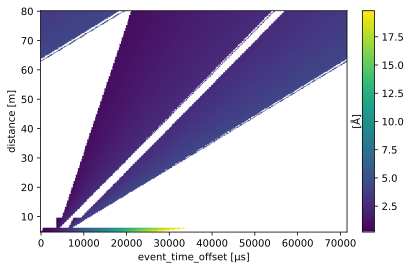

In [5]:
table.plot()

## Save to file

In [6]:
table.save_hdf5('DREAM-high-flux-wavelength-lut-5m-80m-bc240.h5')